# Обучение с учителем: качество модели

**Название проекта:** Модель предсказания покупательской активности клиентов интернет-магазина "В один клик"
____________

**Описание исследования**
"В один клик" - это многопрофильный интернет-магазин, решения в данной компании принимаются на основе данных и бизнес-моделирования. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Необходимо разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.
_____________

**Цель исследования**
Подобрать оптимальную модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца. Используя данные модели и данные о прибыльности клиентов, разработать предложения по увеличению покупательской активности в выбранном сегменте.
______________

**Задачи**

1. Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
2. В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
3. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.
___________

**Исходные данные**
1. market_file.csv: таблица с данными о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
2. market_money.csv: таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
3. market_time.csv: таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
4. money.csv: таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

Данные можно скачать по ссылке: https://drive.google.com/drive/folders/1A8PE8M0o5WuNUe63f_a2YPsZqSZaszvR?usp=sharing
_________
**Данное исследование разделим на несколько частей.**
*Часть 1. Изучение общей информации*
1. Загрузка необходимых импортов.
2. Фиксация констант.
3. Загрузка файлов с данными, получение общей информации.
*Часть 2.Предобработка данных*
1. Поиск пропусков в данных, скрытых и явных дубликатов.
2. Исправление опечаток и разночтений.
3. Приведение данных к нужному для исследования типу.
*Часть 3. Исследовательский анализ данных*
1. Графическое изображение распределения признаков в данных.
2. Выявление возможного дисбаланса признаков целевого класса.
3. Поиск возможных аномалий и выбросов.
4. Отбор клиентов с покупательской активностью не менее трёх месяцев
*Часть 4. Объединение таблиц*
1. Объединение данных market_file.csv, market_money.csv, market_time.csv.
2. Удаление айди, несоответствующих условиям исследования.
*Часть 5. Корреляционный анализ*
1. Проведения корреляционного анализа признаков в количественной шкале в итоговой таблице для моделирования.
*Часть 6. Пайплайны*
1. Разделение данных на тестовую и тренировочную выборку, кодирование категориальных и масштабирование количественных признаков.
2. Обучение моделей KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression(), SVC() с подбором гиперпараметров.
3. Выбор оптимальной модели.
*Часть 7. Анализ важности признаков*
1. Оценка важности признаков для лучшей модели, графическое отображение важности с использованием метода SHAP.
2. Выводы о наиболее и наименее значимых для модели признаков.
*Часть 8. Сегментация покупателей*
1. Сегментация покупателей по выбранному условия на результатах моделирования и данных о прибыльности покупателей.
2. Графическое и аналитическое исследование группы покупателей.
3. Выводы и предложения по работе с сегментом для увеличения покупательской активности.
*Часть 9. Общий вывод*


**Источники данных**

1. **market_file.csv**: Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
2. **market_money.csv**: Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
3. **market_time.csv**: Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
4. **money.csv**: Таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

## Загрузка данных

In [ ]:
# выполним все необходимые импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#библиотека phik для корреляции
!pip install phik -q
import phik

#библиотека shap для оценки важности признаков
!pip install shap -q
import shap

#класс для разделения выборки
from sklearn.model_selection import train_test_split

# класс pipeline
from sklearn.pipeline import Pipeline

# классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

# для работы с пропусками
from sklearn.impute import SimpleImputer

# для работы с метриками
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform, randint
from sklearn.metrics import f1_score

# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# нужные модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# константы
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [ ]:
# загрузка файлов
df_market_file = pd.read_csv('/datasets/market_file.csv')
df_market_money = pd.read_csv('/datasets/market_money.csv')
df_market_time = pd.read_csv('/datasets/market_time.csv')
df_money = pd.read_csv('/datasets/money.csv', sep=';')

In [ ]:
df_market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [ ]:
df_market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [ ]:
df_market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [ ]:
df_money.head()

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"


**Вывод по Шагу 1**

Была выполнена загрузка данных. Данные в таблицах соответствуют описанию

## Предобработка данных

**Датафрейм market_file**

In [ ]:
df_market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [ ]:
#проверим столбцы типа object на скрытые дубликаты и некорректное написание категорий
object_columns = df_market_file.select_dtypes(include='object')
for col in object_columns.columns:
    print(f"Уникальные значения для столбца '{col}':\n{object_columns[col].unique()}\n")

Уникальные значения для столбца 'Покупательская активность':
['Снизилась' 'Прежний уровень']

Уникальные значения для столбца 'Тип сервиса':
['премиум' 'стандартт' 'стандарт']

Уникальные значения для столбца 'Разрешить сообщать':
['да' 'нет']

Уникальные значения для столбца 'Популярная_категория':
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']



In [ ]:
#переименуем разночтения в категориях
df_market_file['Тип сервиса'] = df_market_file['Тип сервиса'].str.replace('стандартт', 'стандарт')

In [ ]:
df_market_file['Популярная_категория'] = df_market_file['Популярная_категория'].str.replace('Косметика и аксесуары', 'Косметика и аксессуары')

In [ ]:
df_market_file['Тип сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [ ]:
#проверим, что после изменений в столбце 'Тип сервиса' не появились дубликаты
df_market_file.duplicated().sum()

0

In [ ]:
df_market_file['id'].duplicated().sum()

0

**Датафрейм market_money**

In [ ]:
df_market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [ ]:
# проверка на пропуски
df_market_money.isna().sum()

id         0
Период     0
Выручка    0
dtype: int64

In [ ]:
df_market_money['Период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [ ]:
#необходимо проверить, точно ли препредыдущий месяц - это не опечатка
df_market_money[df_market_money['Период'] == 'препредыдущий_месяц']

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
6,215350,препредыдущий_месяц,4826.0
11,215351,препредыдущий_месяц,4793.0
13,215352,препредыдущий_месяц,4594.0
...,...,...,...
3885,216643,препредыдущий_месяц,4704.0
3890,216644,препредыдущий_месяц,5299.0
3893,216645,препредыдущий_месяц,5334.0
3895,216646,препредыдущий_месяц,4725.0


In [ ]:
#в датасете 1300 уникальных айди. Соответственно данные показаны по каждому айди в разрезе трех месяце
df_market_money['id'].nunique()

1300

In [ ]:
# проверка на дубликаты
df_market_money.duplicated().sum()

0

**Датафрейм market_time**

In [ ]:
df_market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [ ]:
# проверка на пропуски
df_market_time.isna().sum()

id        0
Период    0
минут     0
dtype: int64

In [ ]:
df_market_time['Период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [ ]:
# была найдена опечатка
df_market_time['Период'] = df_market_time['Период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

In [ ]:
df_market_time['Период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

In [ ]:
# проверка на дубликаты
df_market_time.duplicated().sum()

0

**Датафрейм money**

In [ ]:
df_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1300 non-null   int64 
 1   Прибыль  1300 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.4+ KB


In [ ]:
df_money.isna().sum()

id         0
Прибыль    0
dtype: int64

In [ ]:
# изменение типа данных в столбце "Прибыль"
def convert_currency(val):
    new_val = val.replace(',', '.')
    return float(new_val)

df_money['Прибыль'] = df_money['Прибыль'].apply(convert_currency)

In [ ]:
df_money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [ ]:
# проверка на дубликаты
df_money.duplicated().sum()

0

**Выводы по Шагу 2**

В ходе предобработки данных:
1. Исправлены разночтения для столбца 'Тип сервиса' в данных market_file.csv.
2. Изменён тип данных для столбца 'Прибыль' в данных money.csv
3. Исправлена опечатка для столбца 'Период' в данных market_time.csv.

Дубликатов в данных нет.

## Исследовательский анализ данных

**Датасет market_file**

In [ ]:
# характеристики датасета df_market_file
df_market_file.describe()

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


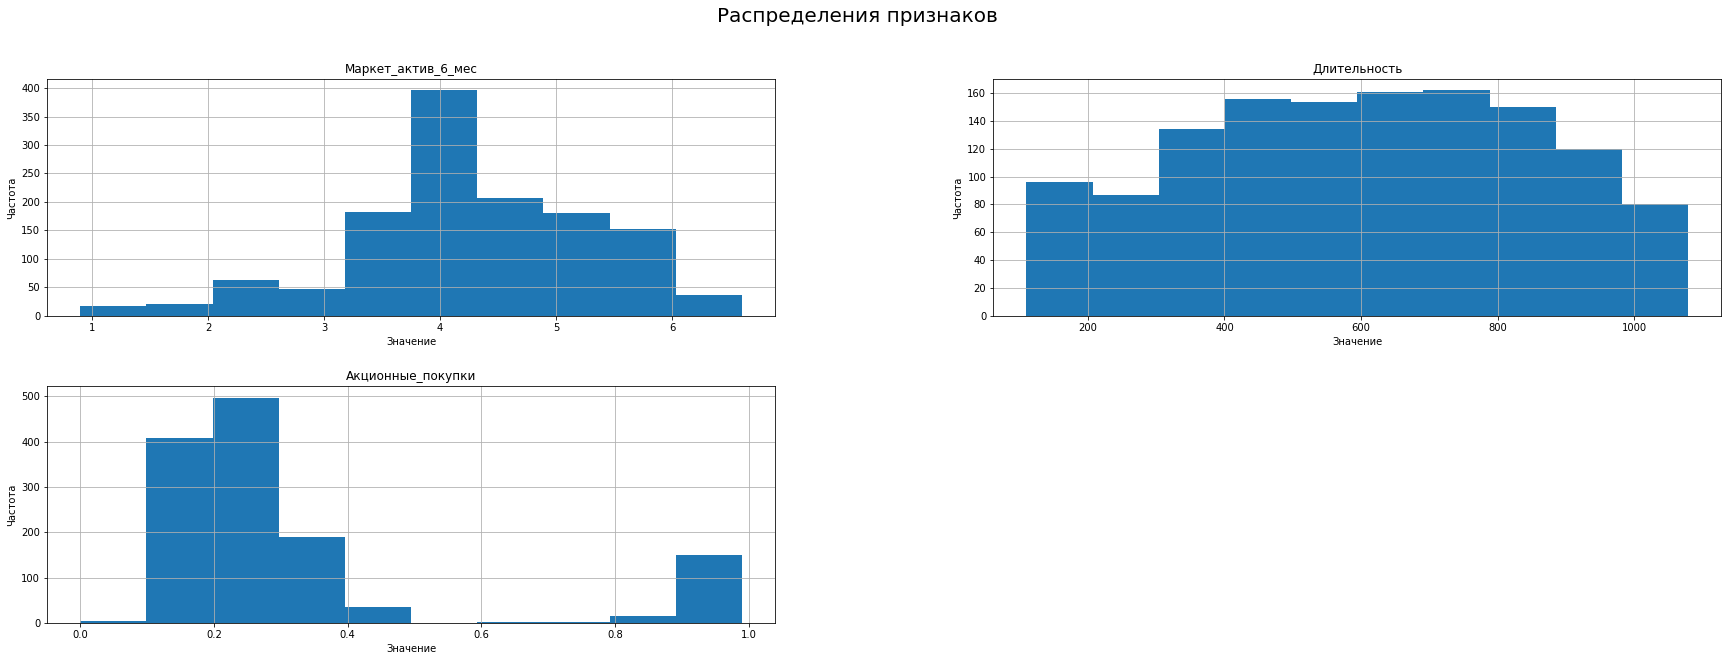

In [ ]:
# гистограммы по датасету df_market_file
fig = df_market_file[['Маркет_актив_6_мес', 'Длительность',
                      'Акционные_покупки']].hist(figsize=(30, 10))

fig = plt.gcf()

for ax in fig.axes:
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

plt.suptitle('Распределения признаков', fontsize=20)
plt.show()

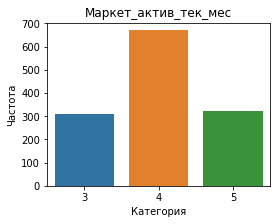

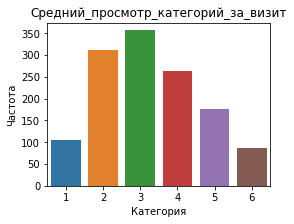

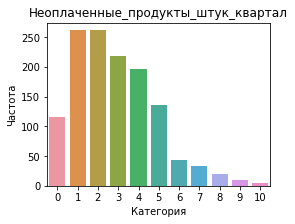

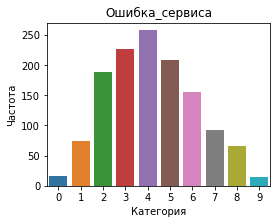

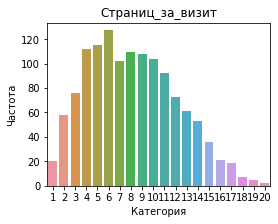

In [ ]:
for col in df_market_file[['Маркет_актив_тек_мес', 'Средний_просмотр_категорий_за_визит',
                          'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
                          'Страниц_за_визит']].columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_market_file, x=col)
    plt.xlabel('Категория')
    plt.ylabel('Частота')
    plt.title(col)
    plt.show()

no boxplot for ID


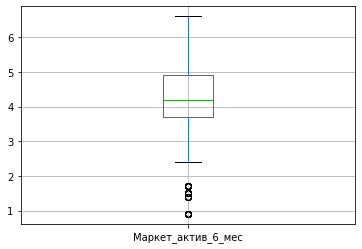

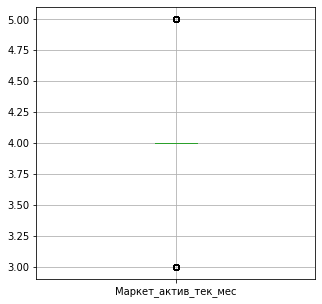

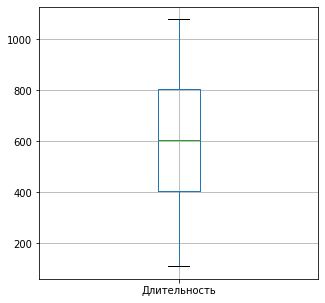

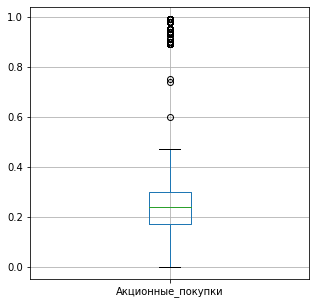

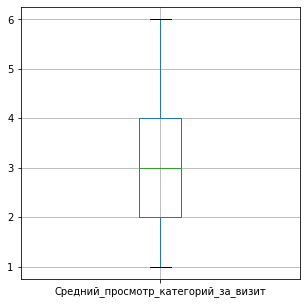

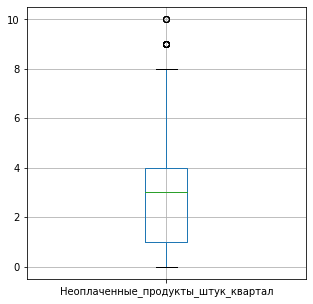

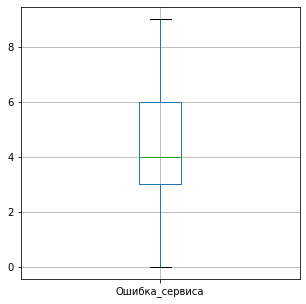

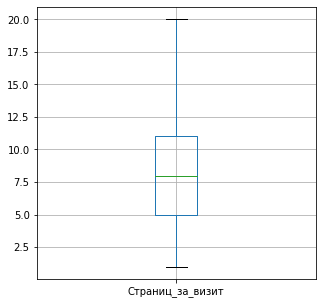

In [ ]:
# графики "ящик с усами" для датасета df_market_file
market_file_boxplot = df_market_file.select_dtypes(include=['float64', 'int64'])
for col in market_file_boxplot.columns:
    if col != 'id':
        df_market_file.boxplot(col)
        plt.rcParams["figure.figsize"] = (5,5)
        plt.show()
    else:
        print('no boxplot for ID')

По графикам боксплота выбросов нет. Несмотря на то, что некоторые данные находятся за "усами" графика, диапазион значений небольшой и такие точки нельзя отнести к выбросам

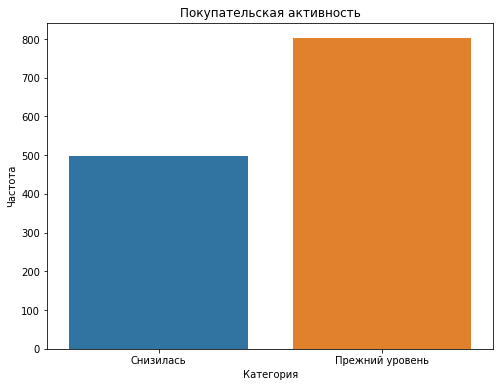

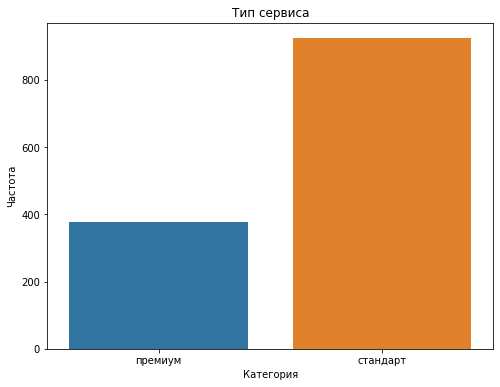

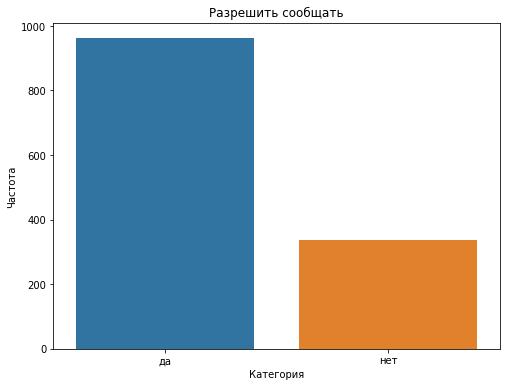

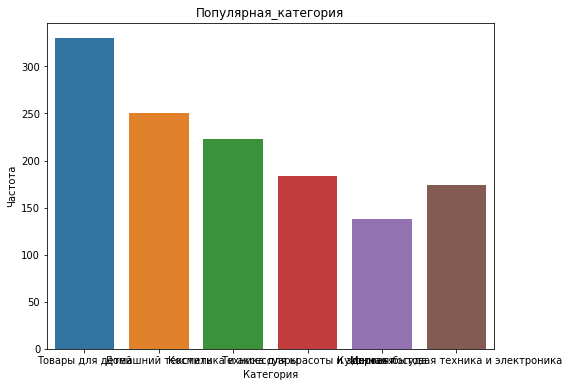

In [ ]:
# столбчатый график, распределение признаков в датасете df_market_file
for col in object_columns.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_market_file, x=col)
    plt.xlabel('Категория')
    plt.ylabel('Частота')
    plt.title(col)
    plt.show()

Тут стоит отметить, что классы, в том числе целевой, несбалансированы. Это будет актуально при дальнейшей подготовки ML модели для выборка корректной метрики качества модели.

**Датасет market_money**

In [ ]:
# характеристики датасета df_market_money
df_market_money['Выручка'].describe()

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: Выручка, dtype: float64

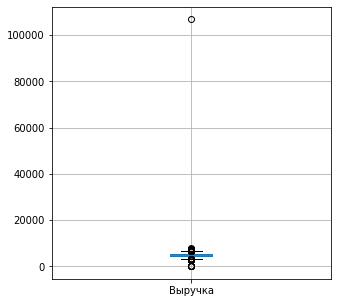

In [ ]:
# ящик с усами по выручке
df_market_money.boxplot(['Выручка'])
plt.rcParams["figure.figsize"] = (5,5)
plt.show()

In [ ]:
# поиск айди с аномальной выручкой
df_market_money[df_market_money['Выручка'] > 100000]

,id,Период,Выручка
98,215380,текущий_месяц,106862.2


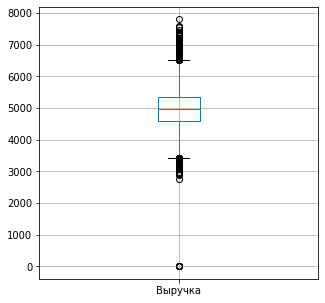

In [ ]:
# ящик с усами без учета айди с аномальной выручкой
df_market_money[df_market_money['Выручка'] < 100000].boxplot(['Выручка'])
plt.rcParams["figure.figsize"] = (5,5)
plt.show()

# данный график более чётко показывает настоящее распределение данных. Много значений находятся за пределами верхней и нижней границы

В датасете есть айди с очень большой выручкой. Соответствующая точка на графике "ящик с усами" выглядит как выброс, так как находится далеко от верхней границы и сильно больше медианы. Если построить аналогичный график без этого значения, данные распределены равномернее. Несмотря на это, было принято решение не удалять записи этого айди. В интернет-магазине могут быть дорогостоящие покупки или очень большие заказы, которые бывают редко.

**Датасет market_time**

In [ ]:
# характеристики датасета df_market_time
df_market_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

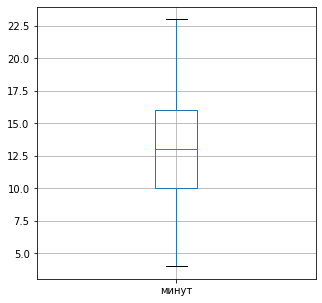

In [ ]:
# распределение признака "минут"
df_market_time.boxplot(['минут'])
plt.rcParams["figure.figsize"] = (5,5)
plt.show()

# на графике видно, что данные не выходят за верхнюю и нижнюю границу, нет смещения данных, они симметрично расположены

**Датасет money**

In [ ]:
# характеристики датасета df_money
df_money['Прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

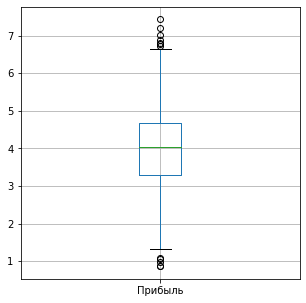

In [ ]:
# ящик с усами для признака Прибыль
df_money.boxplot(['Прибыль'])
plt.rcParams["figure.figsize"] = (5,5)
plt.show()

# данные плотно сгруппированы вокруг медианного значения, симметричны, но есть точки находящиеся за пределами границ

Для дальнешего анализа необходимо отобрать клиентов с покупательской активностью не менее трёх месяцев. Отбор айдишек будет проводить по второму датасету, так как он показывает данные по прибыли от клиента

**Вывод по EDA**

**Датасет market_file.csv:**

1. *Покупательская активность*: это целевой признак в данном исследовании и важная метрика для бизнеса. Более половины клиентов поддерживают текущий уровень активности. Но 38% покупателей со снижающейся покупательской активности - это много, необходимо продумать программу по реактивации и увеличению их LTV.

2. *Тип сервис*: 30% клиентов выбирает премиальный сервис. Увеличить эту долю поможет создание акций для изменений тарифа, скидки на первый месяц использования премиального тарифа.

3. *Разрешить сообщаться*: 26% пользователей отвказываются получить предложения по товарам. Стоит пересмотреть стратегию маркетинговых рассылок. Возможно, они были через чур активными и клиенты отказались от их получения.

4. *Маркет_актив_6_мес*: бОльшая часть клиентов получало 4 маркетинговые рассылки в месяц за последние полгода. Данные распределены относительно равномерно.

5. *Маркет_актив_тек_мес*: в текущем месяца в среднем клиент получает 4 рассылки.

6. *Длительность*: медианная длительность составляет 606 дней, это более полутора лет. При этом самый старый "клиент" зарегистрировался на сайте почти три года назад. Это говорит нам о лояльности пользователей и их большом lifetime. В принципе, по графику видно, что большая часть пользователей уже давно зарегистрирована на сервисе.

7. *Акционные_покупки*: акционные покупки в большей мере присущи клиентам со снизевшейся активностью.

8. *Популярная_категория*: наиболее популярная категория у пользователей - это "товары для детей", а наименее "кухонная посуда". В зависимости от предпочтений клиента, можно высылать персонализированные рассылки для привлечение в другую категорию. Например, клиенту, покупающему товары для детей, прислать push-уведомление об акции в детской посуде и постепенно привлечь в категорию "кухоннная посуда". Например, рассылка об антипригарочном материале, безопасном для детей.

9. *Средний_просмотр_категорий_за_визит*: в среднем пользователи просматривают товары из трёх категорий во время визита. Тут также может быть актуален совет из пункта 8. При привлечении клиентов в другие категории, число среднего просмотра категорий вырастет.

10. *Неоплаченные_продукты_штук_квартал*: чаще всего у пользователей в корзине остаётся 1-2 товара некупленными. Чтобы это число стремилось к нулю можно прибегнуть к push-уведомлениям - напоминать о покупке, давать скидку на товары из корзины.

11. *Ошибка_сервиса*: большое число ошибок ведёт к уходу клиентов в другие сервисы. У большинства клиентов есть ошибки, и их много. Необходимо посмотреть логи и передать разработке.

12. *Страниц_за_визит*: чаще всего пользователи просматривают 6 и более страниц. Это может быть как положительный знак - клиент заинтересован сервисом. Так и негативным - плохо настроена поисковая система и пользовтелю сложно найти нужный товар.
____________
**Датасет market_money.csv**

1. *Выручка*: медианная выручка составляет 5 000 рублей за период. В датасете есть айди с очень большой выручкой. Соответствующая точка на графике "ящик с усами" выглядит как выброс, так как находится далеко от верхней границы и сильно больше медианы. Если построить аналогичный график без этого значения, данные распределены равномернее. Несмотря на это, было принято решение не удалять записи этого айди. В интернет-магазине могут быть дорогостоящие покупки или очень большие заказы, которые бывают редко.
____________

**Датасет market_time.csv**

1. *Минут*: данные распределены симметрично, равномерно, без выбросов. Медианная время, проведённое на сайте - 12,5 минут. Этого времени достаточно для совершения покупки.
_____________

**Датасет money.csv**

1. *Прибыль*: данные плотно сгруппированы вокруг медианного значения. Несмотря на точки находящиеся за пределами границ, выбросов и аномалий нет. Нет клиентов, прибыль от которых сильно больше или меньше средней (4 у.е.)

In [ ]:
df_market_money['Период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [ ]:
df_market_file['Длительность'].max()

1079

In [ ]:
df_market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [ ]:
id_no_purchases = df_market_money['id'][df_market_money['Выручка'] == 0]
id_no_purchases = id_no_purchases.drop_duplicates().tolist()
id_no_purchases
#это айди без покупок

[215348, 215357, 215359]

В ходе исследовательского анализа данных было найдено аномальное значение по выручке в датасете market_money. Было принято рещение не удалять записи соответствующего айди как выброс, так как в интернет-магазине возможны большие покупки.
Три пользователя не попадают под условия для дальнейшего анализа. У них не было покупательской активности в течение последних трёх месяцев. Записи с их айди будут удалены из дальнейших этапов, анализ будет производиться по 1297 клиентам.

## Объединение таблиц

In [ ]:
#словарь для разъединения дф по выручке
dfs = {
    period: subdf[['id', 'Выручка']].reset_index(drop=True)
    for period, subdf in df_market_money.groupby('Период')
}

In [ ]:
#разъединение дф по выручке
df_market_money_lastlast = dfs['препредыдущий_месяц']
df_market_money_lastlast = df_market_money_lastlast.rename(columns={'Выручка': 'Выручка_lastlast'})

df_market_money_last = dfs['предыдущий_месяц']
df_market_money_last = df_market_money_last.rename(columns={'Выручка': 'Выручка_last'})

df_market_money_current = dfs['текущий_месяц']
df_market_money_current = df_market_money_current.rename(columns={'Выручка': 'Выручка_current'})

In [ ]:
df_market_money_lastlast

,id,Выручка_lastlast
0,215348,0.0
1,215349,4472.0
2,215350,4826.0
3,215351,4793.0
4,215352,4594.0
...,...,...
1295,216643,4704.0
1296,216644,5299.0
1297,216645,5334.0
1298,216646,4725.0


In [ ]:
#словарь для разъединения дф по времени
dfs_time = {
    period: subdf[['id', 'минут']].reset_index(drop=True)
    for period, subdf in df_market_time.groupby('Период')
}

In [ ]:
#разъединение дф по времени
df_market_time_last = dfs_time['предыдущий_месяц']
df_market_time_last = df_market_time_last.rename(columns={'минут': 'минут_last'})

df_market_time_current = dfs_time['текущий_месяц']
df_market_time_current = df_market_time_current.rename(columns={'минут': 'минут_current'})

In [ ]:
df_market_time_last

,id,минут_last
0,215348,13
1,215349,12
2,215350,8
3,215351,11
4,215352,8
...,...,...
1295,216643,14
1296,216644,12
1297,216645,12
1298,216646,18


In [ ]:
#подготовка индексов
df_market_money_lastlast = df_market_money_lastlast.set_index('id')
df_market_money_last = df_market_money_last.set_index('id')
df_market_money_current = df_market_money_current.set_index('id')

df_market_time_last = df_market_time_last.set_index('id')
df_market_time_current = df_market_time_current.set_index('id')

df_market_file = df_market_file.set_index('id')

In [ ]:
full_df = pd.concat([df_market_file, df_market_money_lastlast, df_market_money_last,
                    df_market_money_current, df_market_time_last, df_market_time_current], axis=1, join='outer')

In [ ]:
full_df = full_df.reset_index()
full_df = full_df[~full_df['id'].isin(id_no_purchases)].reset_index(drop=True)

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1297 non-null   int64  
 1   Покупательская активность            1297 non-null   object 
 2   Тип сервиса                          1297 non-null   object 
 3   Разрешить сообщать                   1297 non-null   object 
 4   Маркет_актив_6_мес                   1297 non-null   float64
 5   Маркет_актив_тек_мес                 1297 non-null   int64  
 6   Длительность                         1297 non-null   int64  
 7   Акционные_покупки                    1297 non-null   float64
 8   Популярная_категория                 1297 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1297 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 11  Ошибка_сервиса                

На данном этапе таблицы "market_file.csv", "market_money.csv" и "market_time.csv" были объединены в общий датафрейм. Из него были удалены неподходящие под условия айди. Финальный датафрейм для дальнейшего анализа - full_df

## Корреляционный анализ

In [ ]:
interval_columns = full_df[['Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки',
                          'Выручка_lastlast', 'Выручка_last', 'Выручка_current',
                          'минут_last', 'минут_current']]

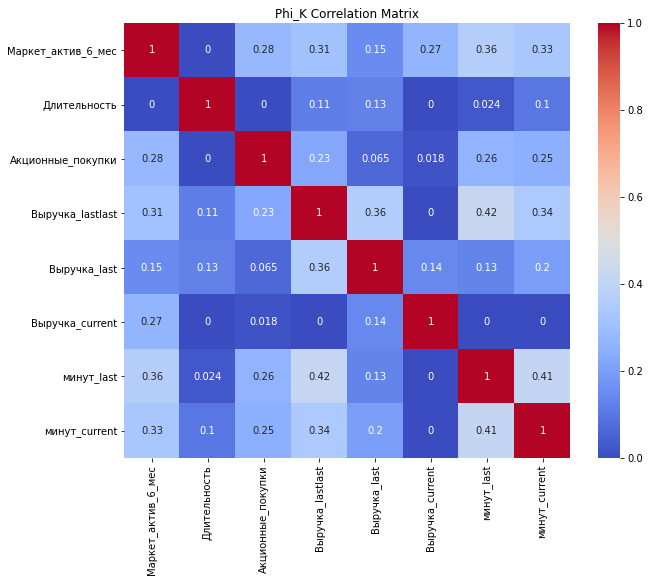

In [ ]:
# Вычисление матрицы корреляции с использованием phik
corr_matrix = full_df[['Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки',
                          'Выручка_lastlast', 'Выручка_last', 'Выручка_current',
                          'минут_last', 'минут_current']].phik_matrix(interval_cols=interval_columns)

# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix')
plt.show()

**Выводы по Шагу 5**

Есть корреляция между признаками "Маркет_актив_6_мес" и "Акционные_покупки". Связь не сильная, но она есть. При узнавании о скидках с помощью маркетинговых активностей, клиент совершал покупки. Помимо этого, среднемесячное значение маркетинговых коммуникаций компании связано с полученной выручкой от клиента в позапрошлом и текущем периоде, а также с временем, проведённом на сайте, в течение прошлого месяца.
Наблюдается связь между временем, проведенном на сайте в прошлом и текущем месяцах. Скорее всего, клиенты, проводившие много минут в прошлом периоде, склоны к этому в текущем.

При этом, мультиколленеарность отсутствует, так как нет чрезвычайно высоких значений корреляции (0,9 и выше).

## Пайплайны

In [ ]:
# разделение выборки на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    full_df.drop(['Покупательская активность', 'id'], axis = 1),
    full_df['Покупательская активность'],
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify = full_df['Покупательская активность']
)

In [ ]:
X_train.shape

(1037, 16)

In [ ]:
X_test.shape

(260, 16)

In [ ]:
# кодировка целевого признака
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [ ]:
y_train.sum() / len(y_train)
#классы целевого признака насбалансированы

0.381870781099325

In [ ]:
full_df.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_lastlast,Выручка_last,Выручка_current,минут_last,минут_current
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10


In [ ]:
full_df['Тип сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

Признак "Тип сервиса" - ранговый

In [ ]:
# создание списка колонок для кодировки
ohe_columns = ['Разрешить сообщать', 'Популярная_категория']
ord_columns = ['Тип сервиса']
num_columns = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки',
              'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал',
              'Ошибка_сервиса', 'Страниц_за_визит', 'Выручка_lastlast', 'Выручка_last', 'Выручка_current',
              'минут_last', 'минут_current']

In [ ]:
# пайплайн для кодировки OneHotEncoder
ohe_pipe = Pipeline([('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))
])

In [ ]:
ord_pipe = Pipeline(
    [
        ('ord', OrdinalEncoder( categories=[['стандарт', 'премиум']],
                               handle_unknown='use_encoded_value',
                               unknown_value=np.nan
                              )
        )
    ]
)

In [ ]:
# кодировка и масштабирование данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ],
    remainder='passthrough'
)

In [ ]:
# финальный пайплайн с предобработкой и выбором модели
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [ ]:
# параметры моделей
param_grid = [
    # Словарь модели DecisionTreeClassifier(
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'models__min_samples_split': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # Словарь модели KNeighborsClassifier())
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # Словарь модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear',
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # Словарь модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE, kernel='poly',probability=True)],
        'models__degree': randint(2, 6),
        'models__C': loguniform(1e-3, 1e3),
        'models__gamma': ['scale', 'auto'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]


Для оценки качества модели была выбрана метрика ROC-AUC. Она подходит для задач бинарной классификации. Также, метрика устойчива к дисбалансу и применима при несбалансированных классах.

In [ ]:
# подбор параметров
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
# обучение модели
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse=False))]),
                                                                               ['Разрешить '
                                                                                'сообщать',
                                                                                'Популярная_категория']),
                                                                              ('o

In [ ]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика по кросс валидацинной выборке:', round(randomized_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Разрешить сообщать',
                                                   'Популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('ord',
                                                                   OrdinalEncoder(categories=[['стандарт',
                                                                                               'премиум']],
                                           

In [ ]:
y_test_pred = randomized_search.predict(X_test)
y_test_proba = randomized_search.predict_proba(X_test)
roc_auc_test = round(roc_auc_score(y_test, y_test_proba[:,1]), 2)

print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_test}')

Метрика ROC-AUC на тестовой выборке: 0.93


In [ ]:
f1_score_test = round(f1_score(y_test, y_test_pred, average="macro"), 2)

print(f'F1-score на тестовой выборке: {f1_score_test}')

F1-score на тестовой выборке: 0.89


**Выводы по Шагу 6**

В данном разделе исследования было произведено обучение модели. В пайплайне использовались три метода машинного обучения: дерево решений, метод k-ближайших соседей, логистическая регресси и метод опорных векторов. Наилучшей моделью был выбран метод опорных векторов (SVC) со следуюзими параметрами. Метрика ROC-AUC на тестовой выборке равна 0,93, F1=0,9. Следоватально:
1) модель хорошо отделяет класс 1 от класса 0;
2) почти всегда присваивает объектам положительного класса более высокие вероятности;
3) precision и recall высокие

## Анализ важности признаков

In [ ]:
# обработка тестового датасета X
# расчёт shap_values
X_test_preprocessed = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_test)

best_pipe = randomized_search.best_estimator_
model = best_pipe.named_steps['models']

X_background = shap.sample(X_test_preprocessed, 100, random_state=RANDOM_STATE)

def predict_proba_1(X):
    return model.predict_proba(X)[:, 1]

explainer = shap.KernelExplainer(predict_proba_1, X_background)
shap_values = explainer.shap_values(X_test_preprocessed)

  0%|          | 0/260 [00:00<?, ?it/s]

In [ ]:
# названия признаков
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']

feature_names = []

for name, transformer, columns in preprocessor.transformers_:
    if name != 'remainder':
        if isinstance(transformer, Pipeline):
            last_step = transformer.steps[-1][1]
            if hasattr(last_step, 'categories_'):
                cat_names = [f"{col}_{val}" for col, vals in zip(columns, last_step.categories_) for val in vals]
                feature_names.extend(cat_names)
            else:
                feature_names.extend(columns)
        else:
            feature_names.extend(columns)
    else:
        remainder_cols = [col for col in X_train.columns if col not in (num_columns + ohe_columns)]
        feature_names.extend(remainder_cols)


print("Всего признаков:", len(feature_names))
print("Примеры:", feature_names[:10])


Всего признаков: 23
Примеры: ['Тип сервиса_премиум', 'Тип сервиса_стандарт', 'Разрешить сообщать_да', 'Разрешить сообщать_нет', 'Популярная_категория_Домашний текстиль', 'Популярная_категория_Косметика и аксесуары', 'Популярная_категория_Кухонная посуда', 'Популярная_категория_Мелкая бытовая техника и электроника', 'Популярная_категория_Техника для красоты и здоровья', 'Популярная_категория_Товары для детей']


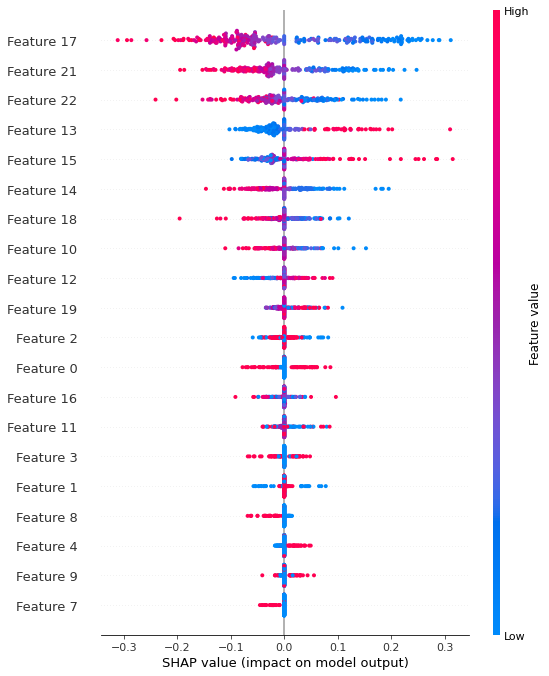

In [ ]:
shap.summary_plot(shap_values, X_test_preprocessed)

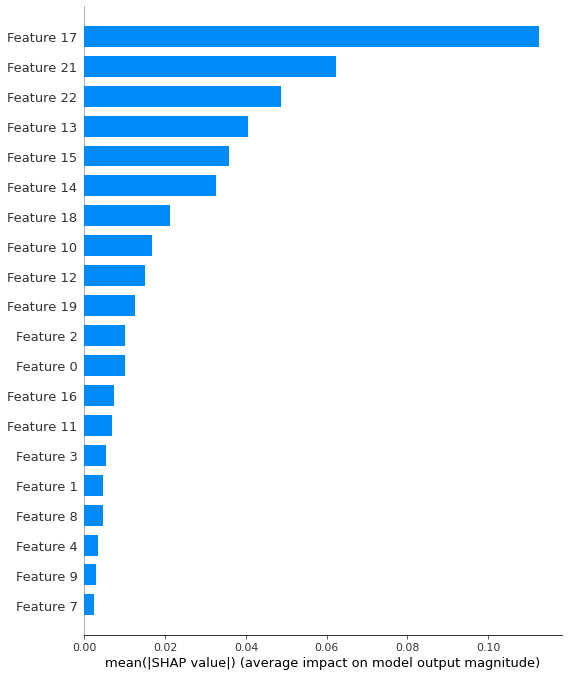

In [ ]:
shap.summary_plot(shap_values, X_test_preprocessed, plot_type="bar")

In [ ]:
print(feature_names[17], feature_names[21], feature_names[22])

Страниц_за_визит минут_last минут_current


In [ ]:
print(feature_names[4], feature_names[9], feature_names[7])

Популярная_категория_Домашний текстиль Популярная_категория_Товары для детей Популярная_категория_Мелкая бытовая техника и электроника


In [ ]:
print(feature_names[13], feature_names[15])

Акционные_покупки Неоплаченные_продукты_штук_квартал


**Выводы по Шагу 7**
1) Наиболее значимыми характеристиками являются число странц, посещенных за визит, время, проведённое на сайте в прошлом и в текущем месяцах. Признак "Страниц_за_визит" является предиктором целевого класса, при этом он имеет обратную зависимость. То есть увеличение признака уменьшает предсказание, выше вероятность класса "0". Аналогично для признаков "минут_last" и "минут_current". Возможно, пользователь проводит много времени на сайте интернет-магазина, просматривает много страниц, потому что не находит подходящих для себя предложений. В связи с чем покупательская активность снижается.


2) Менее всего на целевой признак влияют признаки: 1) Популярная_категория_Домашний текстиль; 2)Популярная_категория_Товары для детей; 3) Популярная_категория_Мелкая бытовая техника и электроника. По первым двум признакам наблюдается прямая зависимость, при выборе этих категорий покупательская активность остаётся на прежнем уровне. А для последнеё категории снижается. Возможно, это связано с тем, что техника - это дорогостоящие покупки с длинным жизненных циклом.

3) Стоит отметить, что признаки "Акционные_покупки" "Неоплаченные_продукты_штук_квартал" положительно влияет на вероятность присваивания класса 1. То есть, если у клиента много акционных покупок и товары в корзине, его покупательская активность не снижается.

**Рекомендации:**
1) При моделировании можно не учитывать неважные признаки.
2) Бизнесу стоит обратить внимание на работу с временем, проведенном на сайте, и количеством просмотренных страниц у клиента. Сейчас пользователи, проводящие много времени на сайте, более склонны к снижению покупательской активности.
3) Вариантом решения может быть контентная оптимизация, улучшние поисковой и рекомендательной системы.

## Сегментация

Выбранный сегмент: Группа клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом.

In [ ]:
#объединяем датафреймы
Train_full = X_train.copy()
Train_full['Класс активности'] = y_train

Test_full = X_test.copy()
Test_full['Класс активности'] = y_test_pred

df_full = Train_full.append(Test_full, ignore_index=False)
df_full = df_full.sort_index()
df_full

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_lastlast,Выручка_last,Выручка_current,минут_last,минут_current,Класс активности
0,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,1
1,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,1
2,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,1
3,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,1
4,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7,0
1293,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,5299.0,4729.0,5353.0,12,11,0
1294,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5334.0,5160.0,5139.2,12,18,0
1295,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7,0


In [ ]:
# добавляем данные по прибыли
df_money = df_money[~df_money['id'].isin(id_no_purchases)].reset_index(drop=True)
df_full['Прибыль'] = df_money['Прибыль']
df_full

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_lastlast,Выручка_last,Выручка_current,минут_last,минут_current,Класс активности,Прибыль
0,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,1,4.16
1,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,1,3.13
2,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,1,4.87
3,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,1,4.21
4,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,1,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7,0,4.44
1293,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,5299.0,4729.0,5353.0,12,11,0,6.11
1294,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5334.0,5160.0,5139.2,12,18,0,3.29
1295,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7,0,4.03


Выбранный сегмент: клиенты, которые покупают только технику, то есть товары с длинным жизненным циклом.
Характеристики выбранного сегмента:
1) Длинный жизненный цикл товара

2) Низкая частота повторных покупок

3) Высокая стоимость чека

Маркетинговые активности слабо влияют на повторные покупки в данной категории. При этом из-за высокого среднего чека прибыль с данного сегмента стабильная, выше среднего, но без заметного роста.

In [ ]:
# сформируем датафрейм с сегментацией, в него входят 357 айди
df_segment = df_full[df_full['Популярная_категория'].isin(['Мелкая бытовая техника и электроника', 'Техника для красоты и здоровья'])]
df_segment.shape

(357, 18)

In [ ]:
# характеристики сегмента
df_segment.describe()

,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_lastlast,Выручка_last,Выручка_current,минут_last,минут_current,Класс активности,Прибыль
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,4.442017,4.028011,612.420168,0.295014,3.414566,2.380952,4.294118,8.890756,4861.394958,4843.901961,5417.686835,14.383754,13.985994,0.212885,3.864426
std,0.940580,0.673995,251.551584,0.237050,1.324620,1.873972,1.966087,3.662266,321.558526,737.382746,5448.877536,3.591667,4.186297,0.409922,1.058184
min,0.900000,3.000000,129.000000,0.110000,1.000000,0.000000,0.000000,1.000000,4165.000000,2890.000000,2758.700000,5.000000,4.000000,0.000000,0.860000
25%,3.900000,4.000000,408.000000,0.160000,2.000000,1.000000,3.000000,6.000000,4611.000000,4358.000000,4599.800000,12.000000,11.000000,0.000000,3.180000
50%,4.300000,4.000000,626.000000,0.230000,3.000000,2.000000,4.000000,9.000000,4852.000000,4902.000000,5062.300000,14.000000,14.000000,0.000000,3.890000
75%,5.100000,4.000000,826.000000,0.280000,4.000000,3.000000,6.000000,11.000000,5092.000000,5315.000000,5624.600000,17.000000,17.000000,0.000000,4.610000
max,6.600000,5.000000,1072.000000,0.990000,6.000000,10.000000,9.000000,19.000000,5663.000000,6588.500000,106862.200000,23.000000,22.000000,1.000000,6.780000


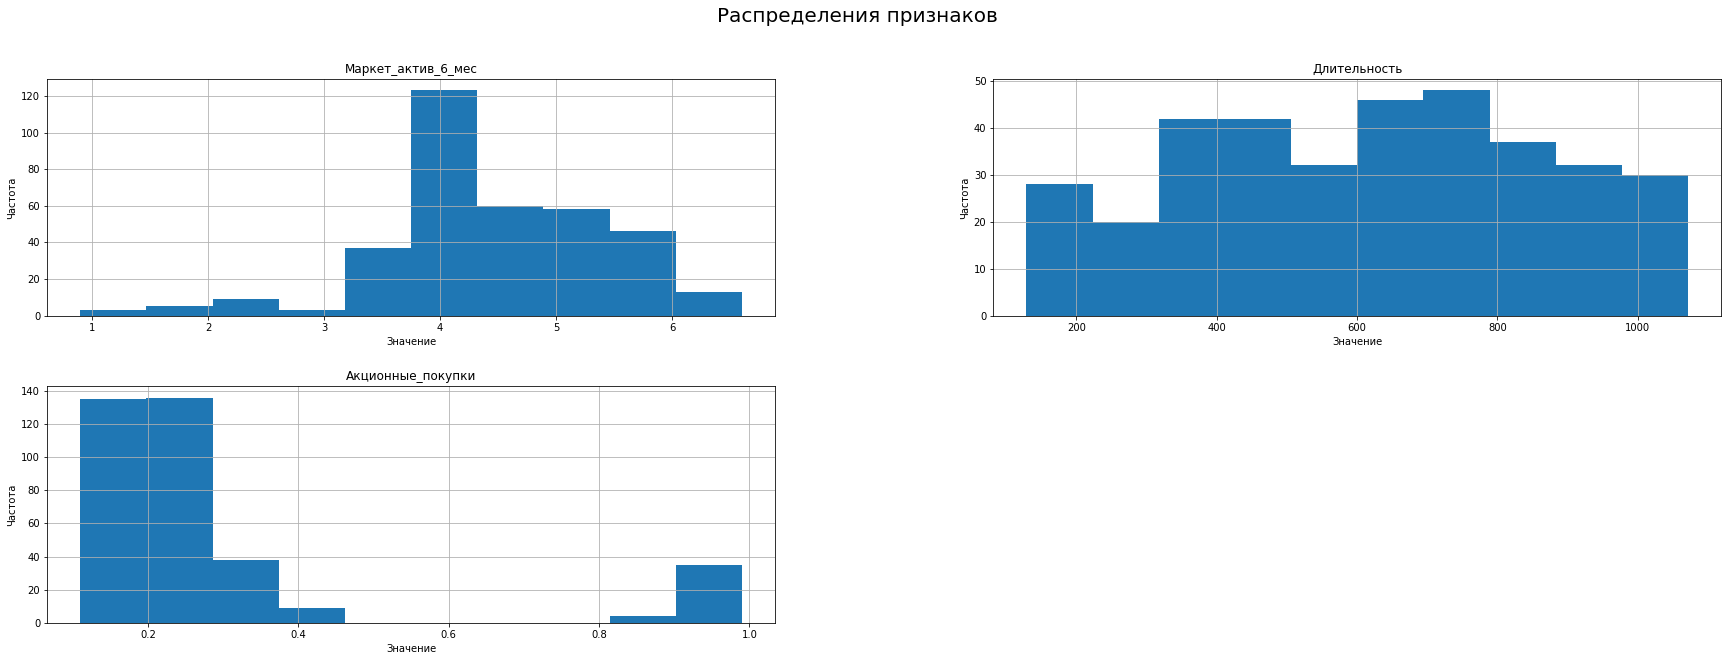

In [ ]:
# гистограммы непрерывных признаков по df_segment

fig = df_segment[['Маркет_актив_6_мес', 'Длительность',
                      'Акционные_покупки']].hist(figsize=(30, 10))

fig = plt.gcf()

for ax in fig.axes:
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

plt.suptitle('Распределения признаков', fontsize=20)
plt.show()

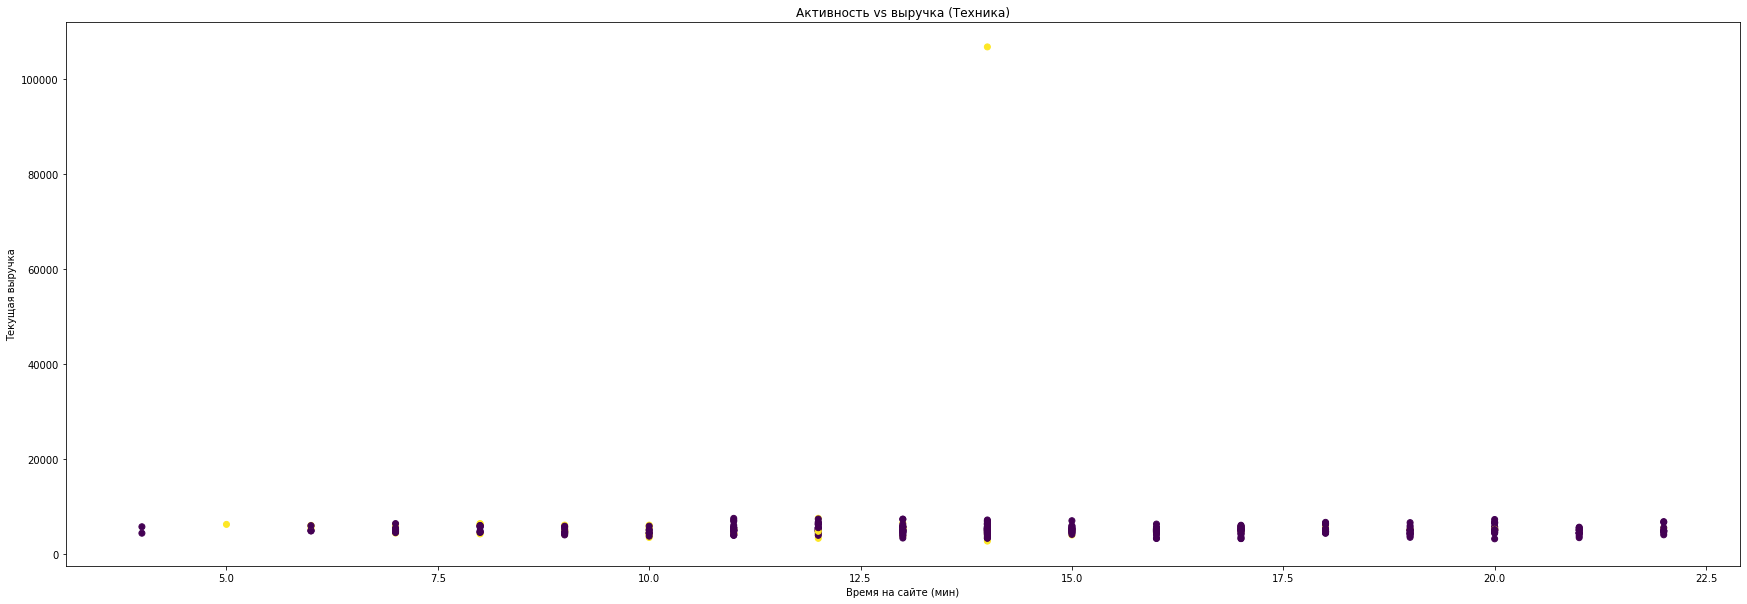

In [ ]:
# рассмотрим зависимость времени, проведённого на сайте, и выручки в текущем периоде в выбранном сегменте.
# Чёткой взаимосвязи между этими характеристиками пользователей нет. Выручка не увеличивается при росте времени.
plt.figure()
plt.scatter(
    df_segment['минут_current'],
    df_segment['Выручка_current'],
    c=df_segment['Класс активности']
)
plt.xlabel('Время на сайте (мин)')
plt.ylabel('Текущая выручка')
plt.title('Активность vs выручка (Техника)')
plt.show()

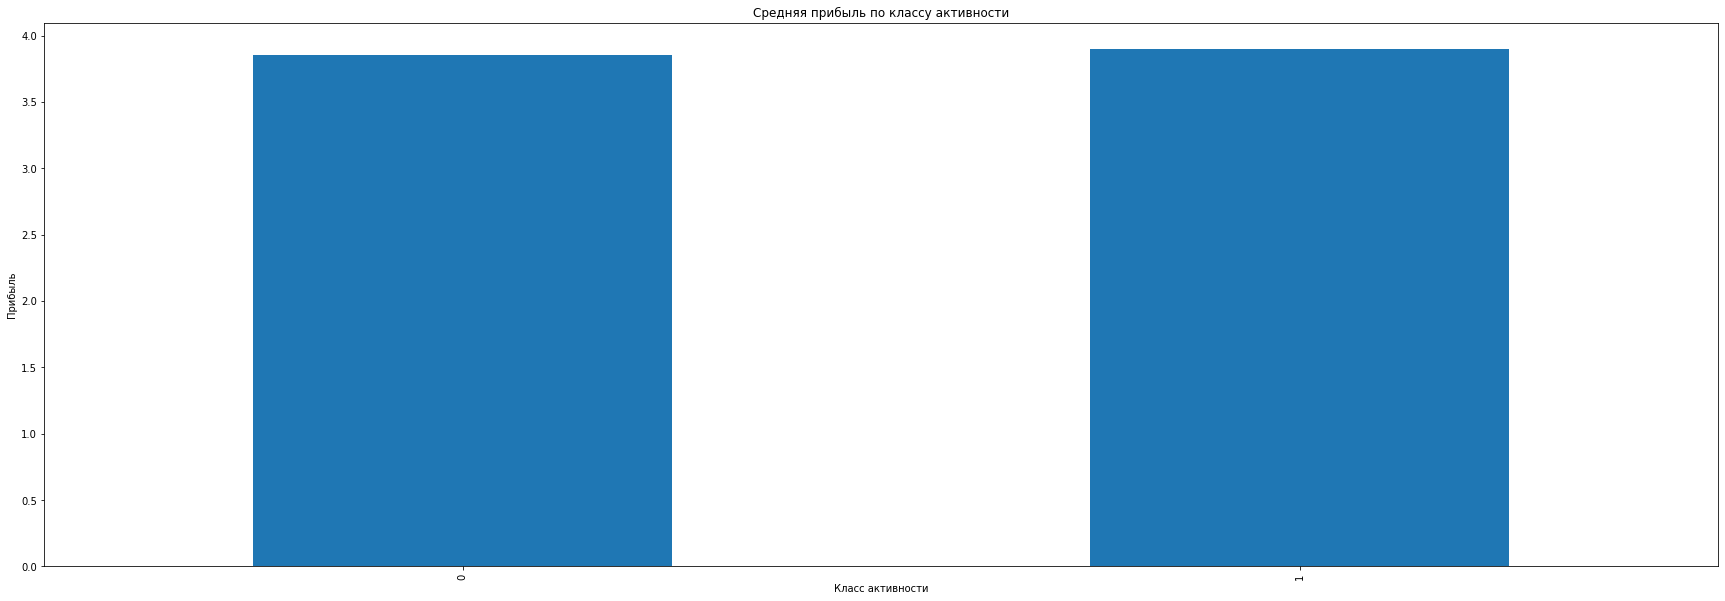

In [ ]:
# посмотрим на распределение прибыли с пользователям по классам активности (целевая переменная).
# 0 - покупательская активность снизилас, 1 - осталась на прежнем уровне
# Магазин получает примерно одинаковую прибыль с каждого покупателя в обоих классах
df_segment.groupby('Класс активности')['Прибыль'].mean().plot(kind='bar')
plt.title('Средняя прибыль по классу активности')
plt.ylabel('Прибыль')
plt.show()

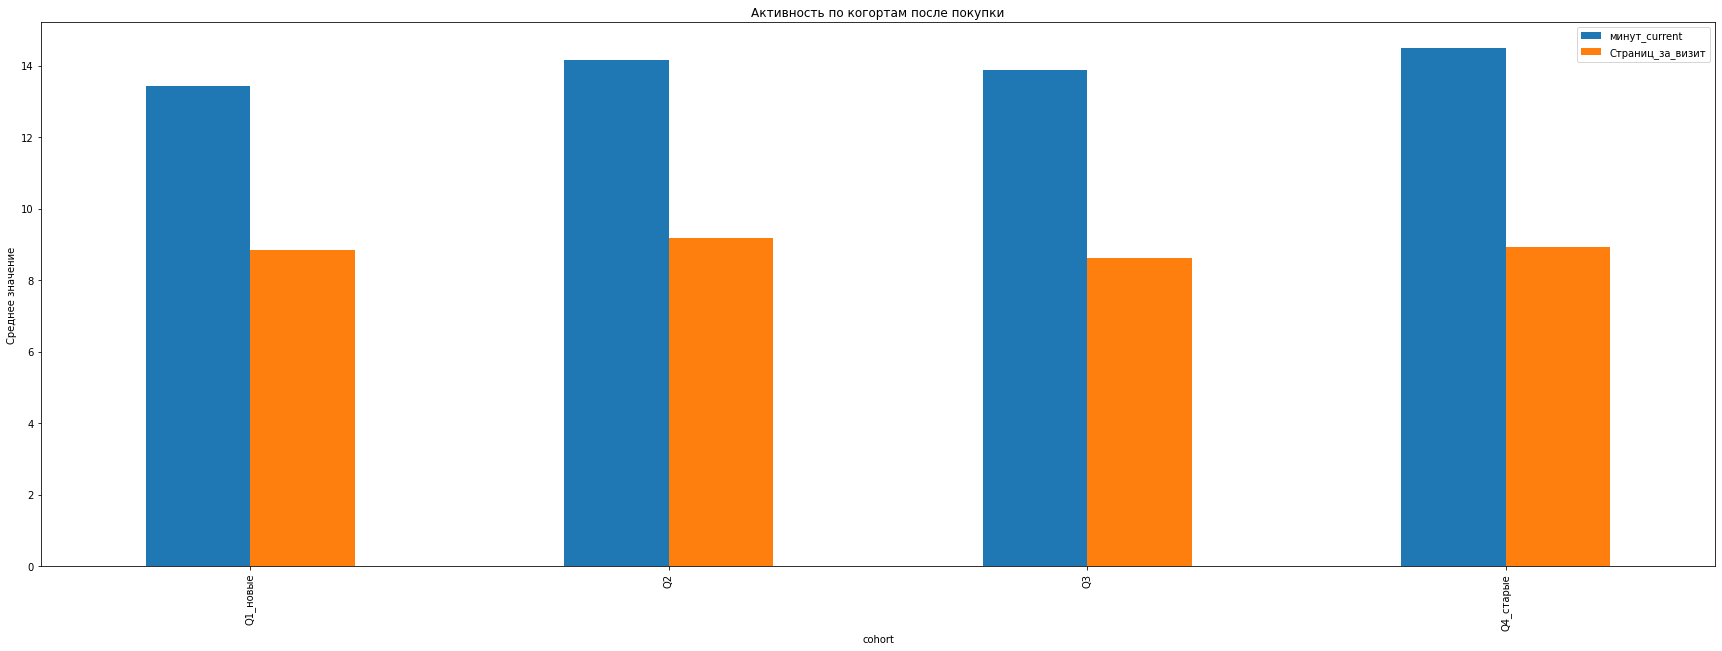

In [ ]:
# Разделим пользователей в сегменте по когортам в зависимости от длительности.
# Признак "Длительность" показывает, сколько дней прошло с момента регистрации покупателя на сайте.
# В когорты Q4_старые войдут пользователи, которые зарегистрировались раньше всего в интернет-магазине, в Q1_новые - новички.
# Количество просмотренных страниц и проведенное время на сайте примерно одинаковое для всех когорт в сегменте.
# Соответственно,нет падения активности и сильной разницы между когортами

tech = df_segment.copy()

tech['cohort'] = pd.qcut(
    tech['Длительность'],
    q=4,
    labels=['Q1_новые', 'Q2', 'Q3', 'Q4_старые']
)

cohort_activity = tech.groupby('cohort')[[
    'минут_current',
    'Страниц_за_визит'
]].mean()

cohort_activity.plot(kind='bar')
plt.title('Активность по когортам после покупки')
plt.ylabel('Среднее значение')
plt.show()

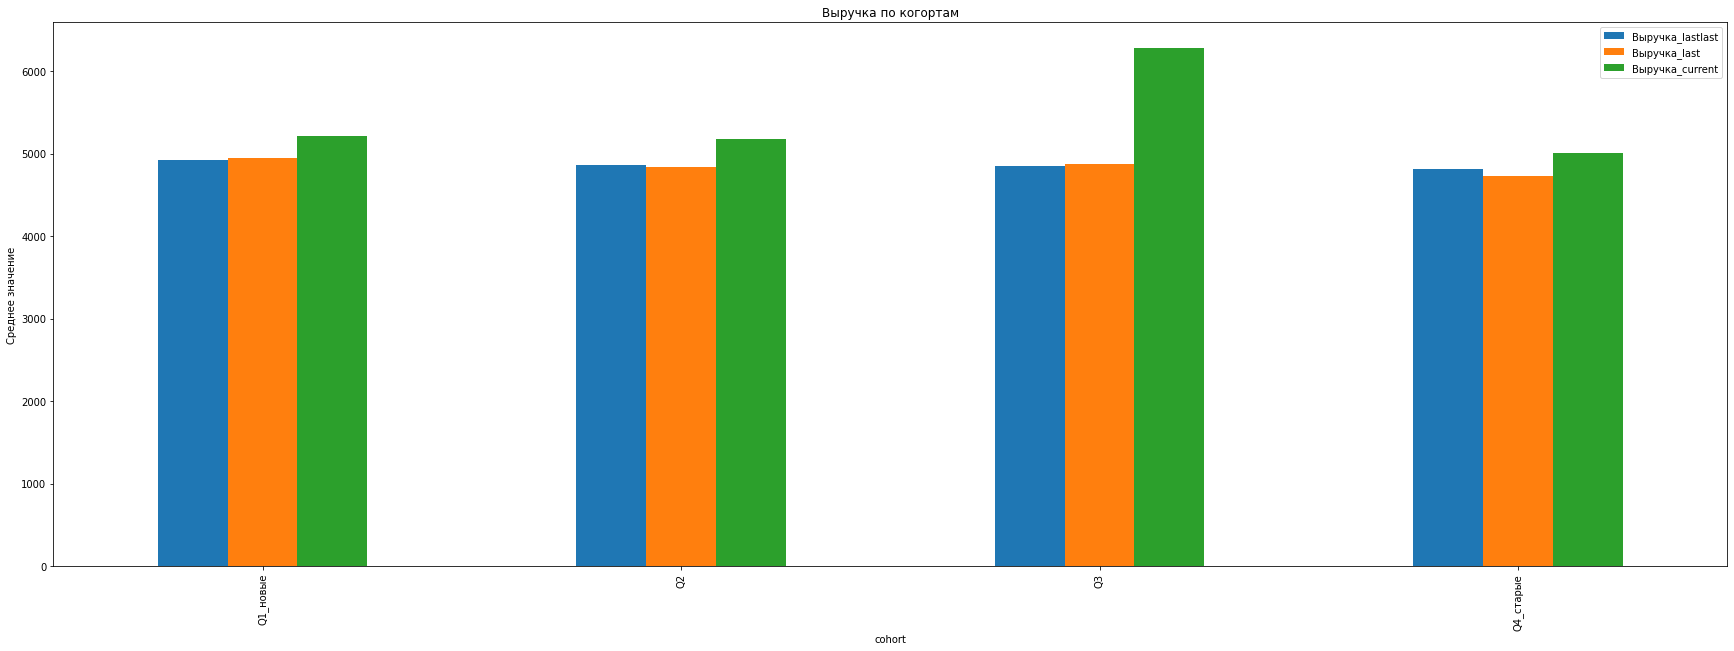

In [ ]:
# Посмотрим на выручку каждой когорте.
# На графике видно, что наибольшая выручкав текущем пеироде от когорты Q3.
# Это может быть связано с тем, что крупную технику покупае. И данная когорта как раз вернулась в интернет-магазин спустя время за большими покупками.
# Также, возможно в эту когорту вошёл пользователь с самым большим чеком в датасете, искуственно завысив метрику.
cohort_money = tech.groupby('cohort')[[
    'Выручка_lastlast',
    'Выручка_last',
    'Выручка_current'
]].mean()

cohort_money.plot(kind='bar')
plt.title('Выручка по когортам')
plt.ylabel('Среднее значение')
plt.show()

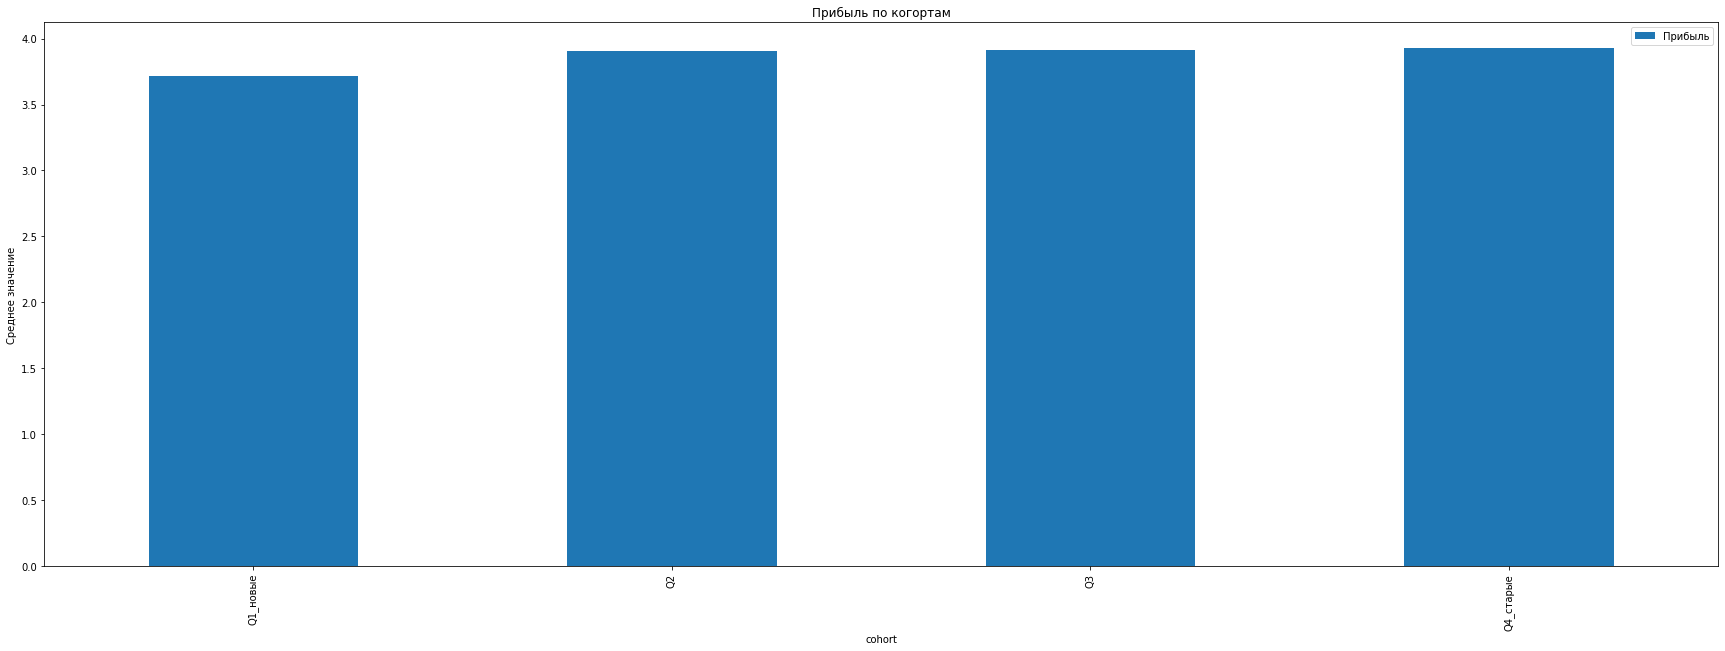

In [ ]:
# пользоваели в каждой когорте приносят примерно одинаковую прибыль
cohort_money = tech.groupby('cohort')[[
    'Прибыль'
]].mean()

cohort_money.plot(kind='bar')
plt.title('Прибыль по когортам')
plt.ylabel('Среднее значение')
plt.show()

In [ ]:
df_segment

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_lastlast,Выручка_last,Выручка_current,минут_last,минут_current,Класс активности,Прибыль
10,стандарт,да,5.1,4,199,0.23,Техника для красоты и здоровья,4,5,2,3,4597.0,6400.0,3789.7,11,13,1,4.03
14,стандарт,да,3.9,4,167,0.95,Техника для красоты и здоровья,6,4,2,5,4190.0,4577.0,4799.3,6,10,1,3.65
17,премиум,да,3.8,5,829,0.24,Техника для красоты и здоровья,2,2,6,1,4536.0,5823.0,5591.6,11,9,1,6.27
27,стандарт,да,1.7,3,488,0.39,Техника для красоты и здоровья,5,1,4,3,4302.0,3543.0,4364.6,12,8,1,3.03
29,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7,5051.0,6077.0,106862.2,12,14,1,3.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,стандарт,да,4.1,4,638,0.22,Техника для красоты и здоровья,4,1,6,14,5176.0,5654.5,6199.2,14,12,0,4.50
1291,премиум,да,4.2,3,991,0.40,Мелкая бытовая техника и электроника,4,3,5,12,5011.0,4589.5,4354.2,19,19,0,5.63
1292,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7,0,4.44
1295,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7,0,4.03


Вывод: Нет падения активности и сильной разницы между когортами

In [ ]:
# чувствительность к маркетингу
tech[[
    'Маркет_актив_тек_мес',
    'Маркет_актив_6_мес',
    'Акционные_покупки',
    'минут_current',
    'Выручка_current',
    'Класс активности'
]].corr()

# По таблице видно, что число акционных покупок влияет на класс активности.
# Это логично, так как покупательская активности напрямую зависит от числа сделанных заказов.
# Также, маркетинговые активности не мотивируют покупателей проводить много времени на сайте и тратить деньги, скорее наоборот.
# Возможно, у компании через чур активный маркетинг


,Маркет_актив_тек_мес,Маркет_актив_6_мес,Акционные_покупки,минут_current,Выручка_current,Класс активности
Маркет_актив_тек_мес,1.000000,0.111128,0.099157,-0.123309,-0.013263,0.037969
Маркет_актив_6_мес,0.111128,1.000000,-0.157571,0.080762,-0.124591,-0.278167
Акционные_покупки,0.099157,-0.157571,1.000000,-0.072166,0.139740,0.328213
минут_current,-0.123309,0.080762,-0.072166,1.000000,-0.010590,-0.279076
Выручка_current,-0.013263,-0.124591,0.139740,-0.010590,1.000000,0.092405
Класс активности,0.037969,-0.278167,0.328213,-0.279076,0.092405,1.000000


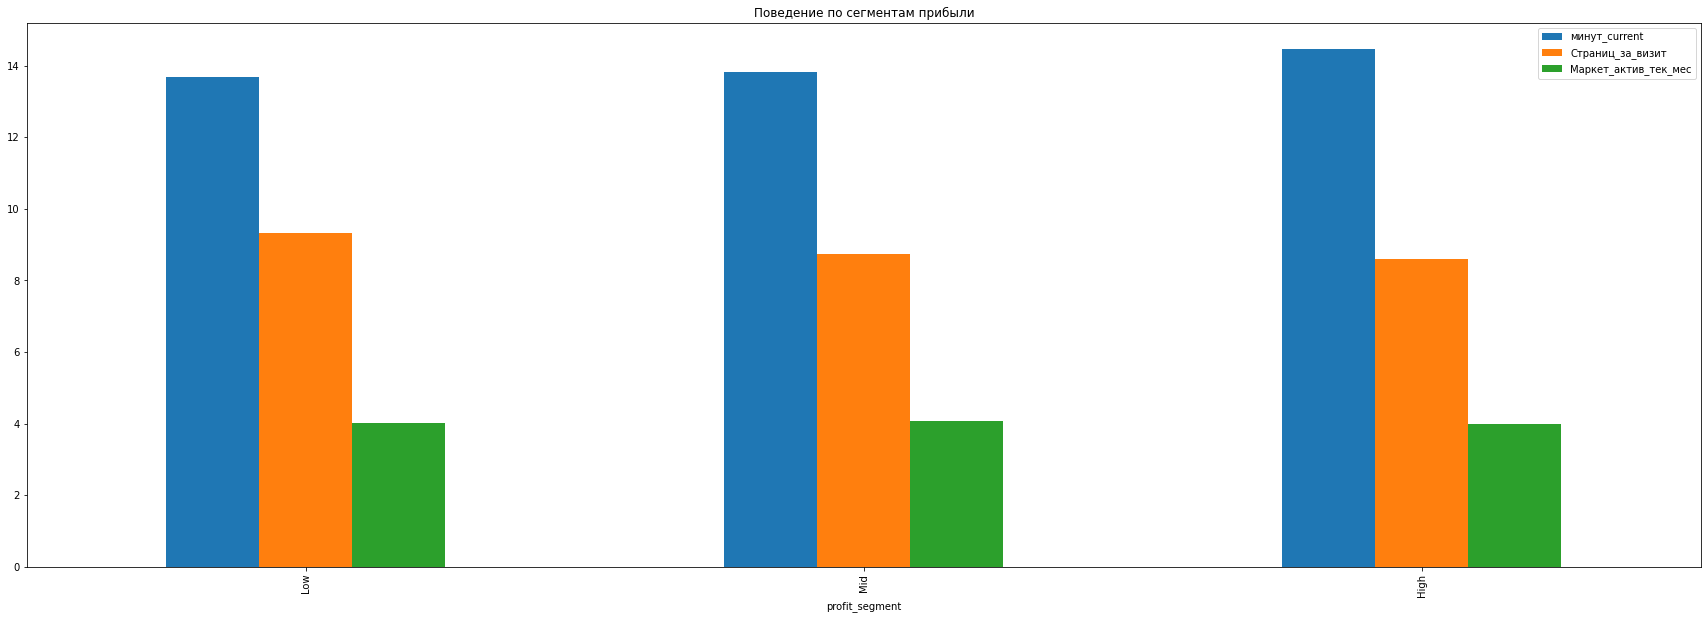

In [ ]:
# Разделим выборку на сегменты по прибыли
# Покупатели из наиболее прибыльного сегмента проводят больше времени на сайте.
tech['profit_segment'] = pd.qcut(
    tech['Прибыль'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

tech.groupby('profit_segment')[[
    'минут_current',
    'Страниц_за_визит',
    'Маркет_актив_тек_мес'
]].mean().plot(kind='bar')

plt.title('Поведение по сегментам прибыли')
plt.show()


In [ ]:
# на данном графике видно, что общая прибыль от класса "1" выше
# при этом, средняя и медианная прибыль немногим выше у класса "1" по сравнению с "0"
# из чего можно сделать вывод, что общая прибыль в классе "1" выше из-за чего большей численности
profit_by_activity = tech.groupby('Класс активности')['Прибыль'].agg(
    mean_profit='mean',
    median_profit='median',
    total_profit='sum',
    count='count'
)

profit_by_activity


,mean_profit,median_profit,total_profit,count
Класс активности,,,,
0,3.854029,3.86,1071.42,278
1,3.901013,4.00,308.18,79


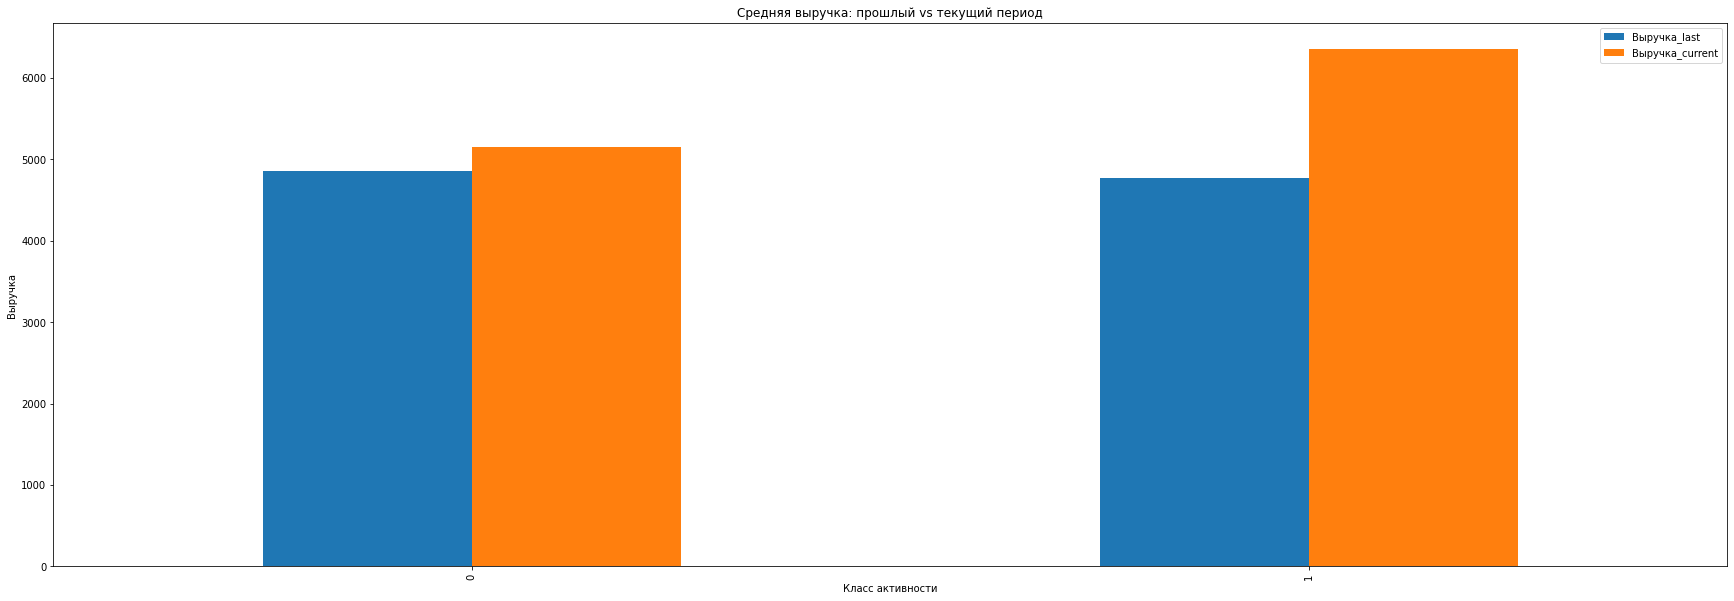

In [ ]:
# клиенты, сохраняющие покупательскую активности (класс 1) приносят бОльшую выручку в текущем периоде
revenue_compare = tech.groupby('Класс активности')[[
    'Выручка_last',
    'Выручка_current'
]].mean()

revenue_compare.plot(kind='bar')
plt.title('Средняя выручка: прошлый vs текущий период')
plt.ylabel('Выручка')
plt.show()

**Вывод по Шагу 8**

Для дополнительного исследования был взят сегмент пользвателей, которые покупают  технику, то есть товары с длинным жизненным циклом.

Предложения по работе с сегментом для увеличения покупательской активности:
1) Сделать маркетинговые рассылки более персонализированы, так как сейчас маркетинговая активность не влияет на ростк покупок в данном сегмент.

2) Добавить новые услуги, например, трейд-ин техники, продажа аксессуаров со скидкой после покупки техники (например, наушники, салфетки для очистки экрана), продажа сопутствующих товаров со скидкой (например, скидка на клавиатуру при покупке монитора), ремонт по гарантии.

3) Мотивировать данных пользователей покупать товары из других категорий. Частые мелкие покупки повысят их LTV.

## Общий вывод ##

**Задачи:**

1) Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.

2) В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.

3) Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

**Исходные данные** включает в себя датасеты: market_file.csv, market_money.csv, market_time.csv, money.csv

**Предобработка данных:**

1) Проверка на явные и скрытые дубликаты: дубликатов нет

2) Проверка на пропуски данных: пропусков нет

3) Исправление опечаток: исправлен "предыдцщий_месяц" в market_time.csv, "стандартт" в market_file.csv

4) Приведение к нужному типу данных: исправлен столбец "Прибыль" в money.csv

5) Поиск аномальных значений и проверка на выбросы: найдено аномальное значение прибыли money.csv, но было принято решение оставить айди с этим значений в датасете, так как в интернет-магазине возможны особо крупные покупки.

**Поиск лучшей модели**
1) Было выполнено кодирование данных с помощью OneHotEncoder и LabelEncoder (целевой признак), масштабирование - StandardScaler, MinMaxScaler.

2) Были обучены модели KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression, SVC.

3) Для подбора параметров использовался RandomizedSearchCV - рандомизированный поиск по параметрам, где каждая настройка выбирается из распределения возможных значений параметров

**Лучшая модель:**
Метод опорных вектором = SVC с полиномиальным ядром.

**Выводы по сегментации:**

Выбранный сегмент: клиенты, которые покупают только технику, то есть товары с длинным жизненным циклом.

*Выводы:*
1) В среднем выручка и прибыль с одного пользователя в данном сегменте не отличается для клиентов, у которых снижается покупательская активность и остаётся на прежнем уровне.
2) Маркетинговые активность не влияют на прибыль и покупательскую активность в данном сегменте.  маркетинговые активности не мотивируют покупателей проводить много времени на сайте и тратить деньги, скорее наоборот. Возможно, у компании через чур активный маркетинг

*Предложения:*
1) Персонализация маркетинговых рассылок.

2) Добавление сопутсвующих услуг и акций.

3) Привлечение пользователей в этом сегмента в другие категории товаров.